_________________

# **Quantitative Portfolio Optimization under ESG and Climate Risk Constraints**

In [ ]:
# Auto reload external python modules
%load_ext autoreload
%autoreload 2

from module.viz import(
    plot_dashboard_portfolio,
    plot_efficient_frontier,
    plot_multiple_frontiers
)

from module.utils import(
    get_portfolio
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
import warnings

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import cvxpy as cp

from sklearn.metrics import (
    silhouette_score
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Config
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

__________

## I. Data Preparation

### Loading data

In [3]:
index_compo = pd.read_excel("data/Indice_de_reference.xlsx", sheet_name='Composition', engine='openpyxl')
benchmark_ = pd.read_excel("data/Indice_de_reference.xlsx", sheet_name='Histo', engine='openpyxl')

In [4]:
prices_ = pd.read_excel("data/Historique_des_cotations.xlsx", engine='openpyxl')

In [5]:
climate_ = pd.read_excel("data/Climate Risk Report.xlsx", sheet_name='Security Data', engine='openpyxl')

In [6]:
esg_ = pd.read_excel("data/DATA_SRI.xlsx", sheet_name='Data', engine='openpyxl')

In [7]:
esg_classes = pd.read_excel("data/DATA_SRI.xlsx", sheet_name='Définition', engine='openpyxl')

### Cleaning Prices data

In [8]:
prices = prices_.copy()

print(prices.shape)
prices.head()

(317639, 3)


,ISIN,Date,Close
0,AT0000652793,2021-07-29,32.36
1,AT0000652793,2021-07-30,32.71
2,AT0000652793,2021-08-02,33.35
3,AT0000652793,2021-08-03,33.31
4,AT0000652793,2021-08-04,33.46


In [9]:
prices = prices.sort_values(["ISIN", "Date"])
prices["return"] = prices.groupby("ISIN")["Close"].pct_change()
prices["return"] = prices["return"].replace([np.inf, -np.inf], np.nan)
prices = prices.dropna(subset=["return"])

print(prices.shape)
prices

(315064, 4)


,ISIN,Date,Close,return
1,AT0000652793,2021-07-30,32.710000,0.010816
2,AT0000652793,2021-08-02,33.350000,0.019566
3,AT0000652793,2021-08-03,33.310000,-0.001199
4,AT0000652793,2021-08-04,33.460000,0.004503
5,AT0000652793,2021-08-05,33.530000,0.002092
...,...,...,...,...
317634,SE0021924911,2024-12-11,20.309990,0.015588
317635,SE0021924911,2024-12-12,20.521739,0.010426
317636,SE0021924911,2024-12-13,20.325662,-0.009555
317637,SE0021924911,2024-12-16,20.433731,0.005317


Before cleaning:
- return distribution: heavily distorted by extreme values reaching up to +100. These values are not economically meaningful and come from data issues, which create artificial spikes when computing percentage changes
- time series: dominated by isolated extreme spikes. These outliers visually distort the volatility pattern and make the series difficult to interpret
- boxplot: completely stretched by extreme outliers, making the interquartile range unreadable

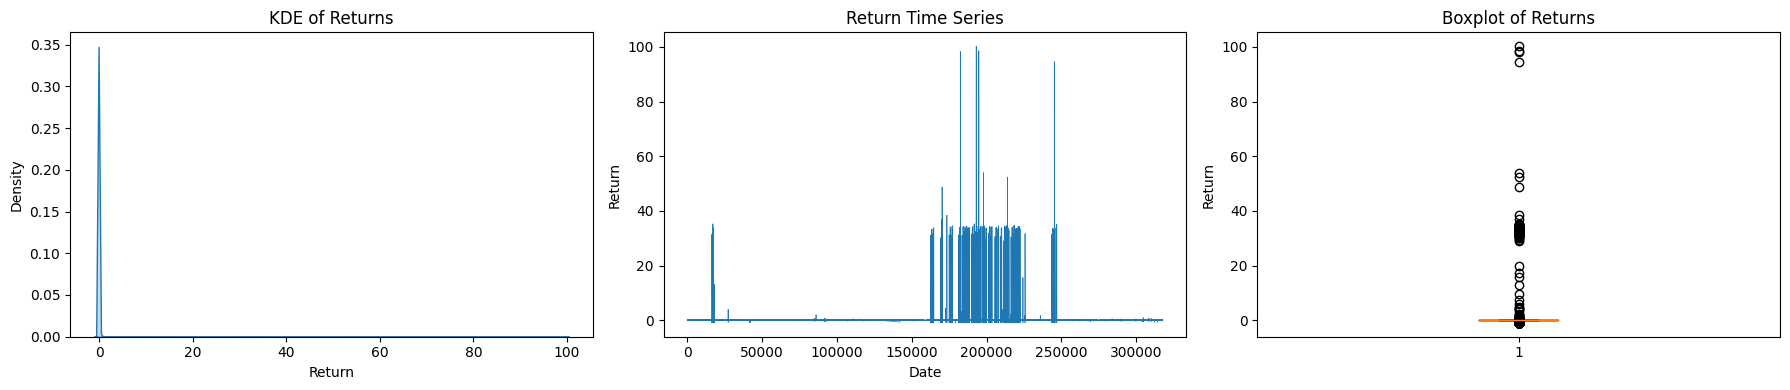

In [10]:
# KDE Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.kdeplot(prices["return"], ax=axes[0], fill=True)
axes[0].set_title("KDE of Returns")
axes[0].set_xlabel("Return")
# Return Time Series
axes[1].plot(prices["return"], linewidth=0.5)
axes[1].set_title("Return Time Series")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Return")
# Boxplot
axes[2].boxplot(prices["return"], vert=True)
axes[2].set_title("Boxplot of Returns")
axes[2].set_ylabel("Return")
plt.tight_layout()
plt.show()

In [11]:
# return bounds
lower_bound = -1  
upper_bound = 1  

# Remove outliers
prices = prices[prices["return"].between(lower_bound, upper_bound)]
print(f"Lower bound: {lower_bound:.4f}, Upper bound: {upper_bound:.4f}")
print(f"Shape after outlier removal: {prices.shape}")

Lower bound: -1.0000, Upper bound: 1.0000
Shape after outlier removal: (314902, 4)


After cleaning:
- return distribution: becomes much more realistic. It is centered around 0 and shows the expected fat-tailed shape of equity returns. This reflects real financial behavior where most returns are small, but extreme events occur with low probability
- time series: becomes stable and interpretable. Returns fluctuate around 0 with visible volatility clustering, a standard property of financial markets. This is now suitable for risk and covariance estimation
- boxplot: distribution becomes well-structured. The median is close to 0, the spread is consistent with daily equity returns. Remaining outliers are economically meaningful and may correspond to real market events such as earnings shocks or corporate announcements

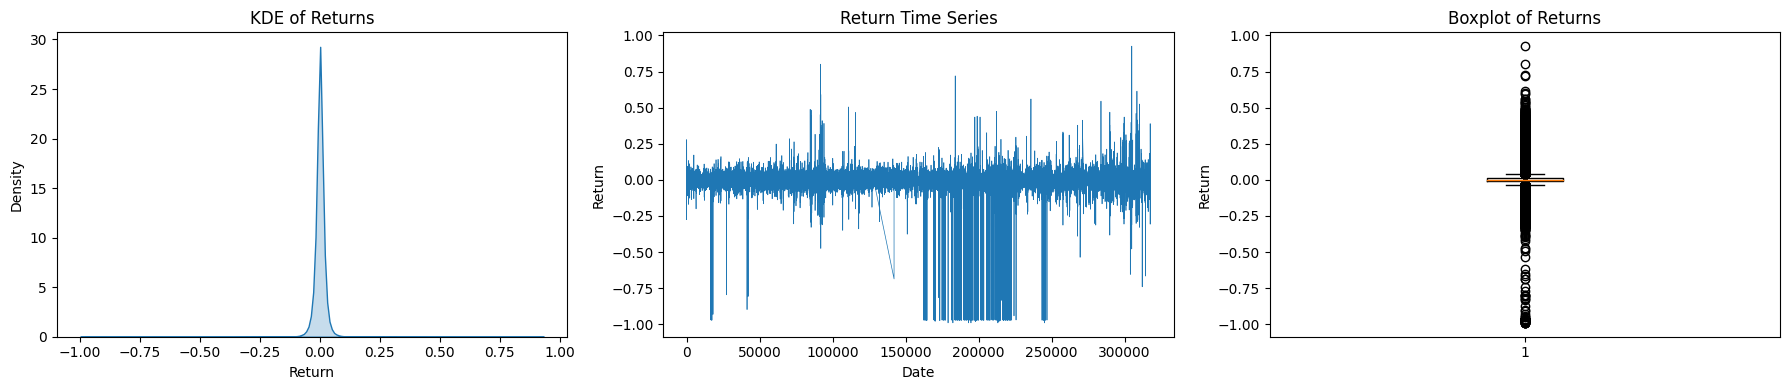

In [12]:
# KDE Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.kdeplot(prices["return"], ax=axes[0], fill=True)
axes[0].set_title("KDE of Returns")
axes[0].set_xlabel("Return")
# Return Time Series
axes[1].plot(prices["return"], linewidth=0.5)
axes[1].set_title("Return Time Series")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Return")
# Boxplot
axes[2].boxplot(prices["return"], vert=True)
axes[2].set_title("Boxplot of Returns")
axes[2].set_ylabel("Return")
plt.tight_layout()
plt.show()

In [13]:
returns = prices.pivot_table(index="Date", columns="ISIN", values="return", aggfunc="last")

print(returns.shape)
returns.head()

(1292, 395)


ISIN,AT0000652793,AT0000743832,AT0000744494,BE0003565426,BE0003604729,BE0003712111,BE0003737005,BE0003793967,BE0003821437,BE0974252089,...,SE0012679298,SE0012853698,SE0014787026,SE0015811623,SE0015941618,SE0015964816,SE0015985970,SE0017489978,SE0017839573,SE0021924911
Date,,,,,,,,,,,,,,,,,,,,,
2019-12-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003718,NaN,...,NaN,NaN,0.001314,NaN,0.006503,NaN,NaN,0.009932,0.008790,0.004801
2019-12-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011151,NaN,...,NaN,NaN,0.097720,NaN,0.006359,NaN,NaN,-0.016463,0.010097,-0.003949
2019-12-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008556,NaN,...,NaN,NaN,0.016993,NaN,0.033269,NaN,NaN,0.000673,0.023263,0.015555
2019-12-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021844,NaN,...,NaN,NaN,0.022984,NaN,0.019049,NaN,NaN,0.008946,0.000818,0.023049
2019-12-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009919,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


At left: We see how many assets are simultaneously observable at each date
* Early sample period shows a reduced cross-section, indicating incomplete universe coverage
* A structural break appears mid-sample where coverage stabilizes around ~300+ assets
* Occasional sharp drops reflect non-trading days or data gaps affecting the full panel


At right: Each point represents an asset and its available time coverage
* Most assets cluster in a high-coverage band (~800–850 observations) 
* A second dense region near full history (~1,200+ observations) 

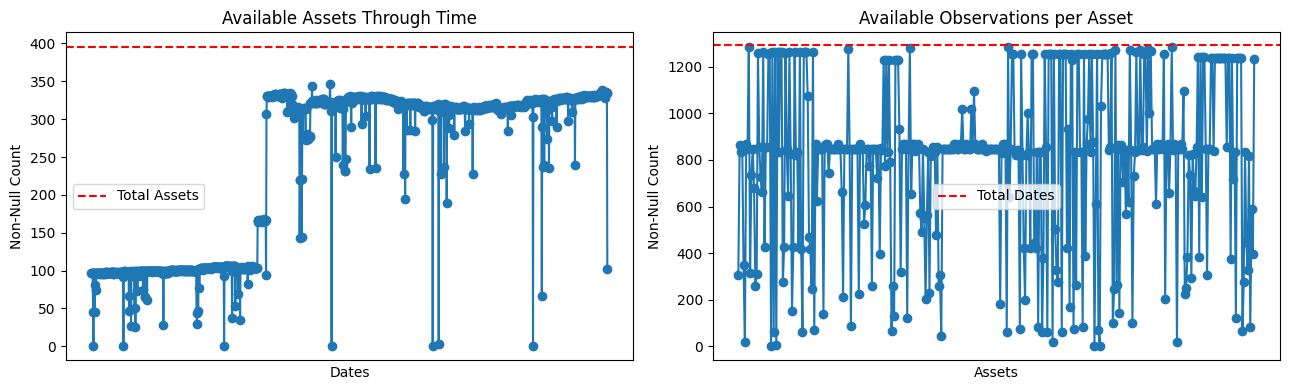

In [14]:
# Non-null counts by date  
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts_dates = returns.count(axis=1)
axes[0].plot(counts_dates.values, marker='o')
axes[0].axhline(
    y=returns.shape[1], color='r', linestyle='--', label='Total Assets'
)
axes[0].set_title("Available Assets Through Time")
axes[0].set_xlabel("Dates")
axes[0].set_ylabel("Non-Null Count")
axes[0].set_xticks([])
axes[0].legend()
# Non-null counts by asset  
counts_assets = returns.count()
axes[1].plot(counts_assets.values, marker='o')
axes[1].axhline(
    y=returns.shape[0], color='r', linestyle='--', label='Total Dates'
)
axes[1].set_title("Available Observations per Asset")
axes[1].set_xlabel("Assets")
axes[1].set_ylabel("Non-Null Count")
axes[1].set_xticks([])
axes[1].legend()
plt.tight_layout()
plt.show()

In [15]:
thresh = int(0.8 * len(returns))
returns = returns.dropna(axis=1, thresh=thresh).dropna(axis=0, how="any")

print("Final shape:", returns.shape)
print("NaN count:", returns.isna().sum().sum())
print("Assets retained:", len(returns.columns))

Final shape: (891, 92)
NaN count: 0
Assets retained: 92


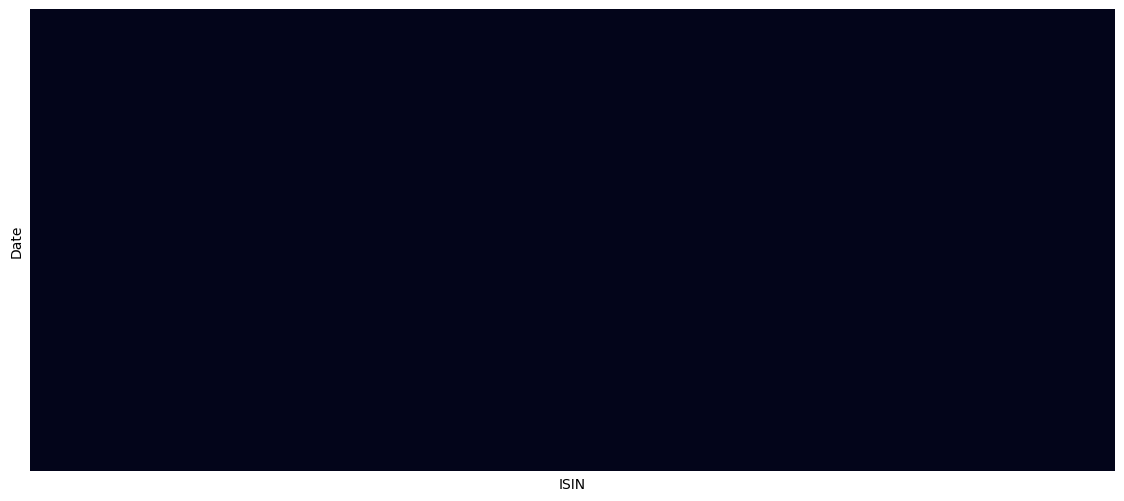

In [16]:
plt.figure(figsize=(14, 6))
sns.heatmap(returns.isna(), cbar=False)
plt.yticks([])
plt.xticks([])
plt.show()

This clustermap displays the correlation structure of the assets, reordered using hierarchical clustering to highlight groups of similar return behavior:
- A clear block of highly correlated assets appears (deep red). These names move closely together, indicating strong shared exposure to common market and macro factors
- The rest of the European universe forms a more fragmented mid-correlation region, with moderate co-movements 

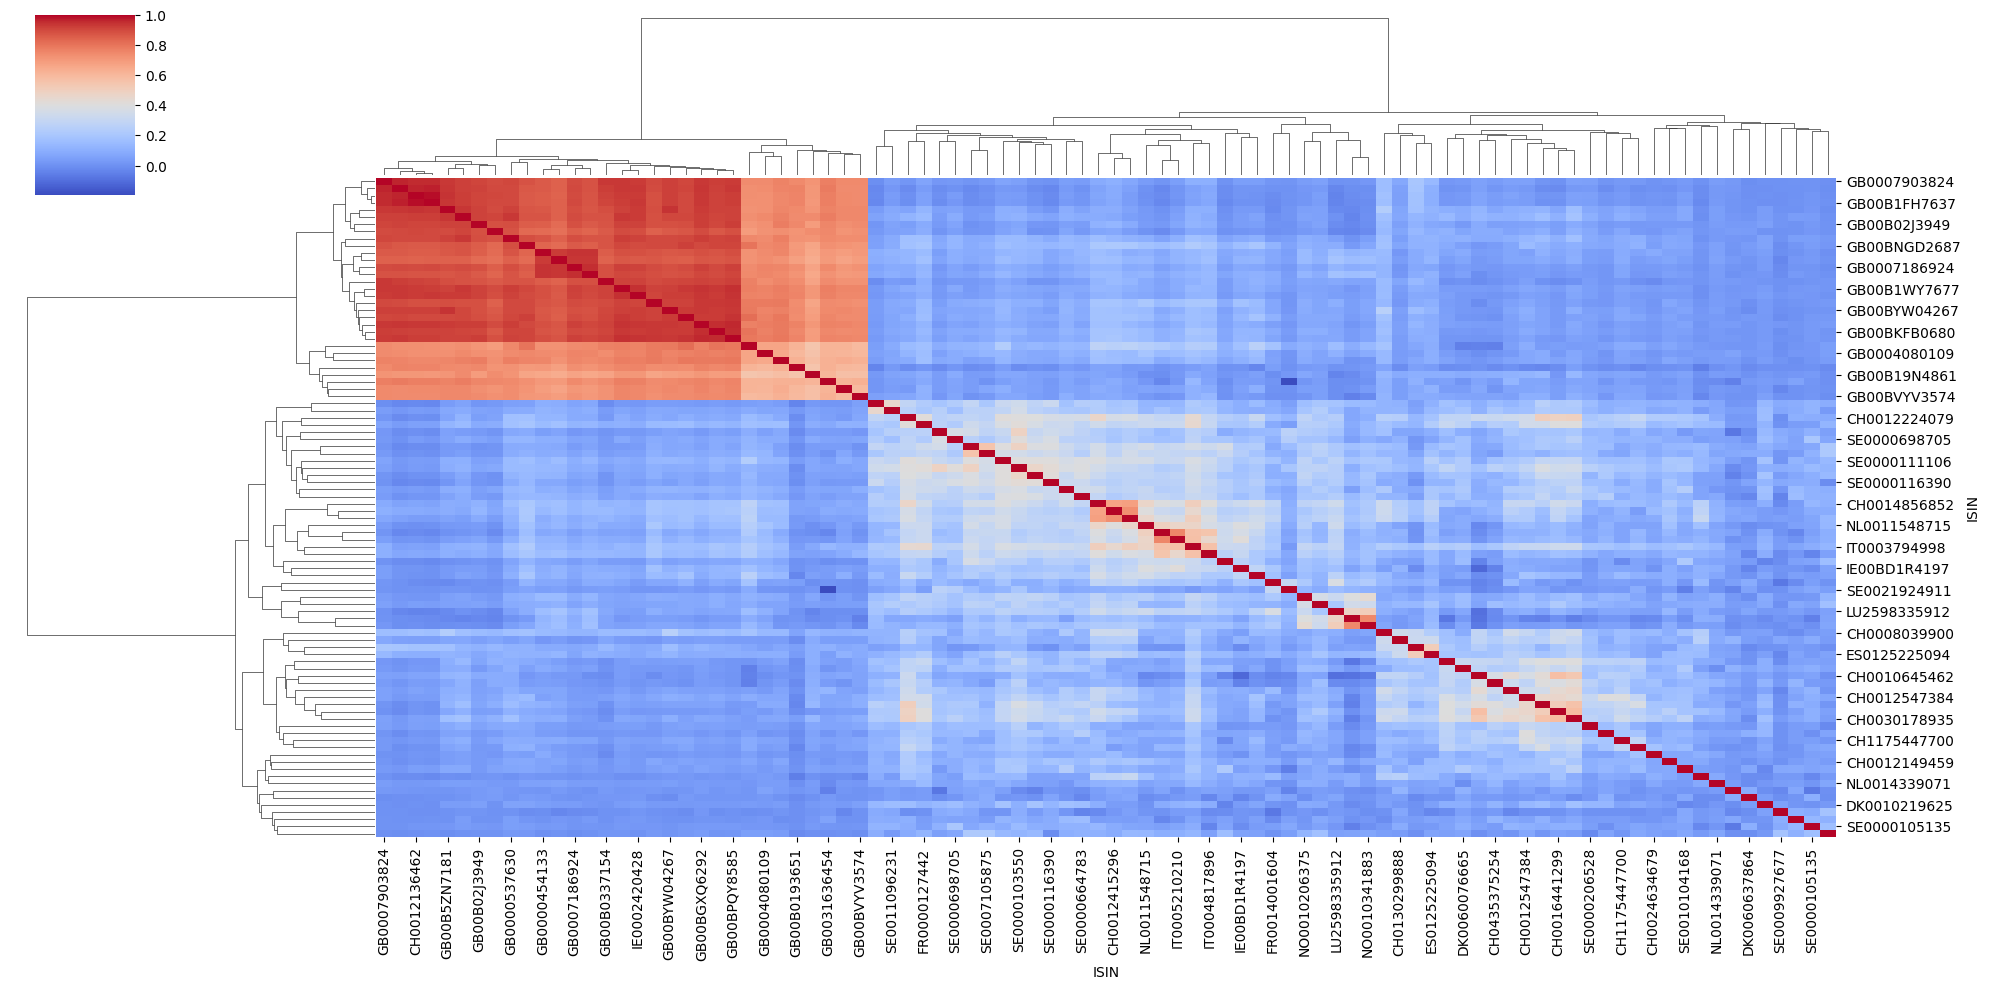

In [17]:
corr = returns.corr()
sns.clustermap(corr, figsize=(20, 10), cmap="coolwarm", cbar=True)
plt.show()

### Cleaning Climate risk data

In [18]:
climate = climate_.set_index("Issuer ISIN").copy()

print(climate.shape)
climate.head()

(405, 131)


,Security ISIN,Enterprise Name,Security Weight,Security Type,Inherited Data,Aggregated Security Climate VaR [%],2°C Aggregated Policy Risk Security Climate VaR (AIM CGE Advance) [%],2°C Aggregated Policy Risk Discounted Costs (AIM CGE Advance) [USD],2°C Policy Risk from Direct GHG Emissions (Scope 1) Security Climate VaR (AIM CGE Advance) [%],2°C Policy Risk from Direct GHG Emissions (Scope 1) Discounted Costs (AIM CGE Advance) [USD],...,Total Scope 3 Estimated [tCO2e/yr],Upstream Scope 3 Estimated [tCO2e/yr],Downstream Scope 3 Estimated [tCO2e/yr],Emissions Scope 3 Category 15: Investments (incl. optional investment categories) [t/y],Total Scope 3 Estimated Revenue Intensity [tCO2e/mUSD/yr],Upstream Scope 3 Estimated Revenue Intensity [tCO2e/mUSD/yr],Downstream Scope 3 Estimated Revenue Intensity [tCO2e/mUSD/yr],Total Scope 3 Estimated EVIC Intensity [tCO2e/mUSD/yr],Upstream Scope 3 Estimated EVIC Intensity [tCO2e/mUSD/yr],Downstream Scope 3 Estimated EVIC Intensity [tCO2e/mUSD/yr]
Issuer ISIN,,,,,,,,,,,,,,,,,,,,,
BE0003604729,BE0003604729,Lo36NV,0.002469,CMN,False,-2.641408,-1.077535,-1.066384e+08,-0.395456,-3.913635e+07,...,7.547976e+05,7.260620e+05,2.873565e+04,NaN,642.818609,618.346076,24.472533,98.022227,94.290455,3.731772
FI4000296904,FI4000296904,No02bp,0.002469,CMN,False,0.882123,-0.744089,-3.043672e+08,-0.002898,-1.185288e+06,...,1.650979e+07,1.545843e+06,1.496394e+07,2.241230e+07,1114.289100,104.333025,1009.956076,58.938758,5.518549,53.420209
GB0032089051,GB0032089051,NE20LC,0.002469,CMN,False,-1.701402,-1.224736,-2.007640e+08,-0.254023,-4.164062e+07,...,1.101693e+06,1.001761e+06,9.993218e+04,NaN,177.768143,161.643183,16.124960,85.236988,77.505327,7.731661
SE0000875075,SE0000875075,Sw08l),0.002469,CMN,False,-3.409905,-0.300466,-3.114834e+07,-0.010380,-1.076041e+06,...,4.020671e+05,2.637618e+05,1.383053e+05,NaN,183.156544,120.153330,63.003214,36.438560,23.904220,12.534340
GB00B24C8278,GB00B24C8278,RE24LC,0.002469,CMN,False,-37.047893,-2.452921,-9.540857e+08,-0.370291,-1.440273e+08,...,1.015015e+07,6.047419e+06,4.102730e+06,NaN,545.091489,324.763360,220.328129,168.481319,100.380505,68.100813


### Physical Risk Clustering

In [19]:
physical_risk_cols = [
    "Aggregated Physical Risk Security Climate VaR (Aggressive outcome) [%]",
    "Coastal Flooding Security Climate VaR (Aggressive outcome) [%]",
    "Fluvial Flooding Security Climate VaR (Aggressive outcome) [%]",
    "Extreme Heat Security Climate VaR (Aggressive outcome) [%]",
    "Wildfire Security Climate VaR (Aggressive outcome) [%]",
    "Tropical Cyclones Security Climate VaR (Aggressive outcome) [%]",
    "Extreme Precipitation Security Climate VaR (Aggressive outcome) [%]",
]
X_phys = climate[physical_risk_cols].copy()

### Elbow Method

In [20]:
X_phys = X_phys.fillna(X_phys.median())

scaler = StandardScaler()
X_phys_scaled = scaler.fit_transform(X_phys)

We used the chart to select the optimal number of clusters for the physical risk segmentation:
- WCSS (blue curve) measures within-cluster compactness. It decreases mechanically as the number of clusters increases, so the key is to identify the point where improvements slow down
- Silhouette score (orange curve) evaluates cluster separation quality

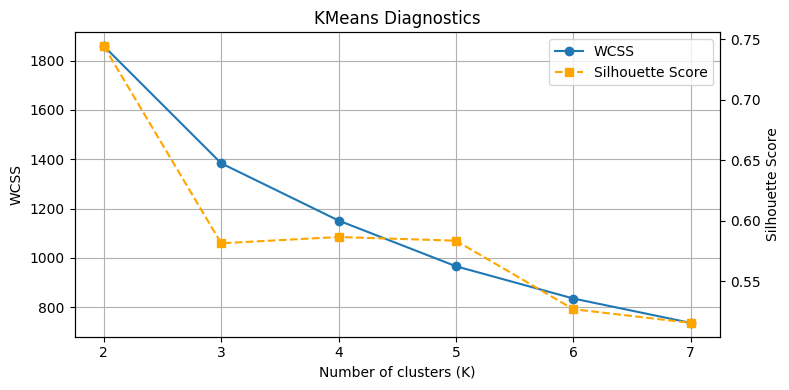

In [21]:
K_range = range(2, 8)
wcss, silhouette_scores = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = km.fit_predict(X_phys_scaled)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_phys_scaled, labels))

# Elbow curve
fig, ax1 = plt.subplots(figsize=(8, 4))
line1 = ax1.plot(K_range, wcss, marker='o', label='WCSS')
ax1.set_xlabel("Number of clusters (K)")
ax1.set_ylabel("WCSS")
ax1.grid(True)
# Secondary axis
ax2 = ax1.twinx()
line2 = ax2.plot(K_range, silhouette_scores, marker='s',
    linestyle='--', label='Silhouette Score', color='orange')
ax2.set_ylabel("Silhouette Score")
# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')
plt.title("KMeans Diagnostics")
plt.tight_layout()
plt.show()

K=4 is selected as a balanced compromise: 
- it preserves stable clustering quality while introducing additional granularity in physical risk segmentation
- improving interpretability for portfolio constraints without over-segmenting the universe

In [22]:
k = 4 
kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_phys_scaled)
climate["PHYSICAL_CLUSTER"] = clusters

In [23]:
climate_cols = physical_risk_cols + ["Implied Temperature Rise [°C]", "Aggregated Security Climate VaR [%]"]
climate = climate[climate_cols+["PHYSICAL_CLUSTER"]].dropna(axis="rows").dropna(axis="columns")

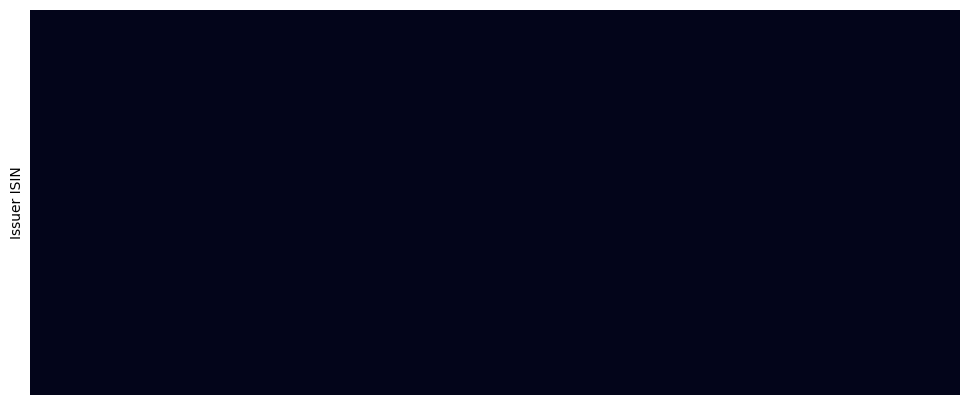

In [24]:
plt.figure(figsize=(12, 5))
sns.heatmap(climate.isna(), cbar=False)
plt.yticks([])
plt.xticks([])
plt.show()

### Cleaning ESG data

In [25]:
esg = esg_.set_index("ISIN").copy()

print(esg.shape)
esg.head()

(23216, 223)


,DATE,ACTIVE_FF_SECTOR_EXPOSURE,ACTIVE_FF_SECTOR_EXPOSURE_SOURCE,ACTIVE_FF_SECTOR_EXPOSURE_YEAR,AE_MAX_REV_PCT,AGG1.5_CLIMATE_VAR,AGG3_CLIMATE_VAR,ALC_MAX_REV,AUDIT_COMMITTEE_EXISTS,AUDIT_COMMITTEE_INDEP_PCT,...,WATER_STRESS_HIGH_RISK_GEO_PCT,WATER_STRESS_MED_RISK_GEO_PCT,WATER_WD_INTEN_RECENT,WEIGHTED_AVERAGE_SCORE,WOMEN_DIRECTORS_PCT,WOMEN_DIRECTORS_PCT_RECENT,WOMEN_EXEC_MGMT_PCT,WOMEN_EXEC_MGMT_PCT_RECENT,WOMEN_WORKFORCE_PCT,WOMEN_WORKFORCE_PCT_RECENT
ISIN,,,,,,,,,,,,,,,,,,,,,
CH0008039900,2020-01-31,NaN,NaN,NaN,NaN,-0.611226,-0.089273,0.3,1.0,100.0,...,0.0,0.0,754.375122,5.8,NaN,28.57,NaN,NaN,NaN,88.2
CH0008039900,2020-02-28,NaN,NaN,NaN,NaN,-0.611226,-0.089273,0.3,1.0,100.0,...,0.0,0.0,754.375122,5.8,NaN,28.57,NaN,NaN,NaN,88.2
CH0008039900,2020-03-31,NaN,NaN,NaN,NaN,-0.611226,-0.089273,0.3,1.0,100.0,...,0.0,0.0,754.375122,5.8,NaN,28.57,NaN,NaN,NaN,88.2
CH0008039900,2020-04-30,NaN,NaN,NaN,NaN,-0.611226,-0.089273,0.3,1.0,100.0,...,0.0,0.0,754.375122,5.8,NaN,28.57,NaN,NaN,NaN,88.2
CH0008039900,2020-05-29,NaN,NaN,NaN,NaN,-0.352043,-0.064041,0.3,1.0,100.0,...,0.0,0.0,754.375122,5.5,NaN,28.57,NaN,NaN,NaN,88.2


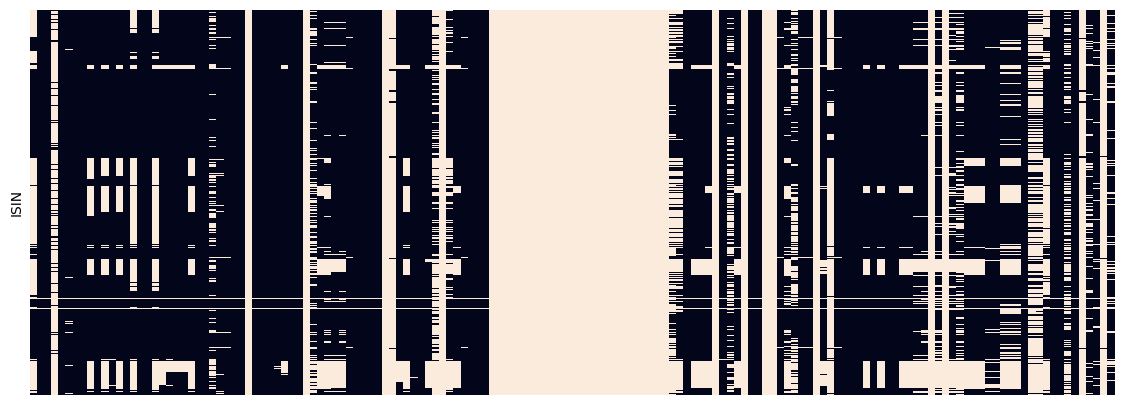

In [26]:
esg_numeric = esg.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 5))
sns.heatmap(esg_numeric.isna(), cbar=False)
plt.yticks([])
plt.xticks([])
plt.show()

In [27]:
esg_category_map = (
    esg_classes.groupby("Categories")["Fields"]
    .apply(list)
    .to_dict()
)

category_scores = pd.DataFrame(index=esg_numeric.index)
for category, fields in esg_category_map.items():
    # keep only existing columns
    valid_fields = [f for f in fields if f in esg_numeric.columns]
    if len(valid_fields) == 0:
        continue
    category_scores[category] = (
        esg_numeric[valid_fields]
        .mean(axis=1)
    )

category_scores_mean = (
    category_scores
    .groupby(level=0)
    .mean()
    .dropna(axis=1, how='any')
)
esg_scores = category_scores_mean.mean(axis=1)
esg_scores.head()

ISIN
AT0000652793    435402.606005
AT0000743832    860093.130748
AT0000744494     20015.100746
BE0003565426    249917.844962
BE0003604729     18096.791505
dtype: float64

### Aligning returns, esg and climate data

In [28]:
assets = list(set(returns.columns) & set(climate.index) & set(esg_scores.index))
print(f"Number of assets with complete data: {len(assets)}")

Number of assets with complete data: 89


### Getting expected returns and covariance matrix

$$\Sigma_{annual} = \Sigma_{daily} \times 252$$

In [29]:
mu = returns[assets].mean() * 252
cov = returns[assets].cov() * 252

physical = climate.loc[assets, physical_risk_cols].mean(axis=1)
itr = climate.loc[assets, "Implied Temperature Rise [°C]"]
cvar = climate.loc[assets, "Aggregated Security Climate VaR [%]"]

esg_scores = esg_scores.loc[assets]

cluster_map = climate.loc[assets, "PHYSICAL_CLUSTER"]

print(f"Expected returns NaN count: {mu.isna().sum()} ; Values: {mu[mu.isna()]}")
print(f"Covariance matrix NaN count: {cov.isna().sum().sum()} ")
print(f"Physical risk NaN count: {physical.isna().sum()} ; Values: {physical[physical.isna()]}")
print(f"ITR NaN count: {itr.isna().sum()} ; Values: {itr[itr.isna()]}")
print(f"CVaR NaN count: {cvar.isna().sum()} ; Values: {cvar[cvar.isna()]}")
print(f"ESG scores NaN count: {esg_scores.isna().sum()} ; Values: {esg_scores[esg_scores.isna()]}")
print(f"Cluster map NaN count: {cluster_map.isna().sum()} ; Values: {cluster_map[cluster_map.isna()]}")

Expected returns NaN count: 0 ; Values: Series([], dtype: float64)
Covariance matrix NaN count: 0 
Physical risk NaN count: 0 ; Values: Series([], dtype: float64)
ITR NaN count: 0 ; Values: Series([], Name: Implied Temperature Rise [°C], dtype: float64)
CVaR NaN count: 0 ; Values: Series([], Name: Aggregated Security Climate VaR [%], dtype: float64)
ESG scores NaN count: 0 ; Values: Series([], dtype: float64)
Cluster map NaN count: 0 ; Values: Series([], Name: PHYSICAL_CLUSTER, dtype: int32)


__________

## II. Optimization



|    Expected portfolio return    |       Portfolio risk (variance)    |
|------|--------|
| $$R_p = \mu^T w = \sum_{i=1}^{N} w_i \mu_i$$    |  $$\sigma_p^2 = w^T \Sigma w = \sum_{i=1}^{N} \sum_{j=1}^{N} w_i w_j \Sigma_{ij}$$  |



<br>



|  Sharpe Ratio  | Tracking Error   |    Diversification Ratio  |
|-----|--------|-------|
|  $$SR = \frac{E[R]}{\sigma}$$ | controls active deviation vs benchmark  <br> $$TE = \sqrt{(w - w_b)^T \Sigma (w - w_b)} $$|  quantifies diversification benefit  <br> $$DR = \frac{\sum w_i \sigma_i}{\sigma_p}$$ |

### Portfolio Constraints

In [30]:
def get_constraints(
    w, tracking_error,
    esg_scores=None, physical=None, itr=None, cvar=None, cluster_map=None,
    portfolio_esg=None, portfolio_phys=None, portfolio_itr=None, portfolio_cvar=None
):
    constraints = [                            
        # Maximum issuer weight (1)
        w <= 0.30,
        # Concentration limit (2)                               
        cp.sum(cp.pos(w - 0.2)) <= 0.40,
        # Fully invested portfolio (5)
        cp.sum(w) == 1,     
        # Long-only portfolio (6)                    
        w >= 0,
    ]
    if portfolio_phys is not None:
        constraints.append(portfolio_phys <= float(physical.mean()))
    if portfolio_itr is not None:
        # Temperature alignment constraint (3)
        constraints.append(portfolio_itr <= 2.0)
        constraints.append(portfolio_itr <= float(itr.mean()))
    if portfolio_cvar is not None:
        # Climate VaR constraint (4)
        constraints.append(portfolio_cvar <= float(cvar.mean()))
    if portfolio_esg is not None:
        constraints.append(portfolio_esg >= float(esg_scores.mean()))
    # Tracking error constraint
    constraints.append(tracking_error <= 0.05)
    # Cluster constraints
    if cluster_map is not None:
        cluster_constraints = []
        for k in sorted(cluster_map.unique()):
            # assets belonging to cluster k
            cluster_assets = cluster_map[cluster_map == k].index
            # indices in optimization vector
            idx = [assets.index(a) for a in cluster_assets]
            # cluster weight constraint
            cluster_constraints.append(
                cp.sum(w[idx]) <= 0.50
            )
        constraints += cluster_constraints
    return constraints

### Objective Function

$$
\max_w \ \underbrace{R_p}_{return}
\ - \ \lambda_r \underbrace{\sigma_p^2}_{financial\ risk}
\ - \ \lambda_{te} \underbrace{PR_p}_{tracking \ error\ risk}$$

In [31]:
def optimize_portfolio(
    assets=assets, mu=mu, cov=cov, 
    physical=None, itr=None, cvar=None, esg_scores=None, cluster_map=None,
    lambda_risk=1, lambda_te=1
):
    # Variables
    n = len(assets)
    w = cp.Variable(n)
    # Tracking Error formulation
    w_b = np.ones(n) / n
    tracking_error = cp.quad_form(w - w_b, cov.values)
    # Portfolio metrics
    portfolio_return = mu.values @ w
    portfolio_risk = cp.quad_form(w, cov.values)
    portfolio_itr, portfolio_esg, portfolio_phys, portfolio_cvar = None, None, None, None
    if physical is not None:
        portfolio_phys = physical.values @ w
    if itr is not None:
        portfolio_itr = itr.values @ w
    if cvar is not None:
        portfolio_cvar = cvar.values @ w
    if esg_scores is not None:
        portfolio_esg = esg_scores.values @ w
    # Constraints
    constraints = get_constraints(w=w, tracking_error=tracking_error,
        esg_scores=esg_scores, physical=physical, itr=itr, cvar=cvar, cluster_map=cluster_map,
        portfolio_esg=portfolio_esg, portfolio_phys=portfolio_phys, portfolio_itr=portfolio_itr, portfolio_cvar=portfolio_cvar,
    )
    # Objective function
    objective = cp.Maximize(
        portfolio_return
        - lambda_risk * portfolio_risk
        - lambda_te * tracking_error
    )
    # Solve the optimization problem
    #print(f"CP Solvers : {cp.installed_solvers()}")
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS, verbose=False)
    return w.value

In [32]:
w_no_env_constr = optimize_portfolio()

In [33]:
w_climate_constr = optimize_portfolio(physical=physical, itr=itr, cvar=cvar)


In [34]:
w_climate_esg_constr = optimize_portfolio(physical=physical, itr=itr, cvar=cvar, esg_scores=esg_scores)

### Comparison

The unconstrained portfolio is highly concentrated:
- A small number of assets receive most of the allocation, with several positions reaching the maximum weight constraint
- This is a standard behavior of mean-variance optimization, which strongly favors assets with the highest risk-adjusted expected returns

In term of performance:
- The optimized portfolio outperforms the benchmark 
- The cumulative return increases substantially faster than the equal-weight benchmark
- This reflects the optimizer’s ability to exploit historical return differences


The portfolio also exhibits the highest exposure to climate risks, including Climate VaR and physical risk measures

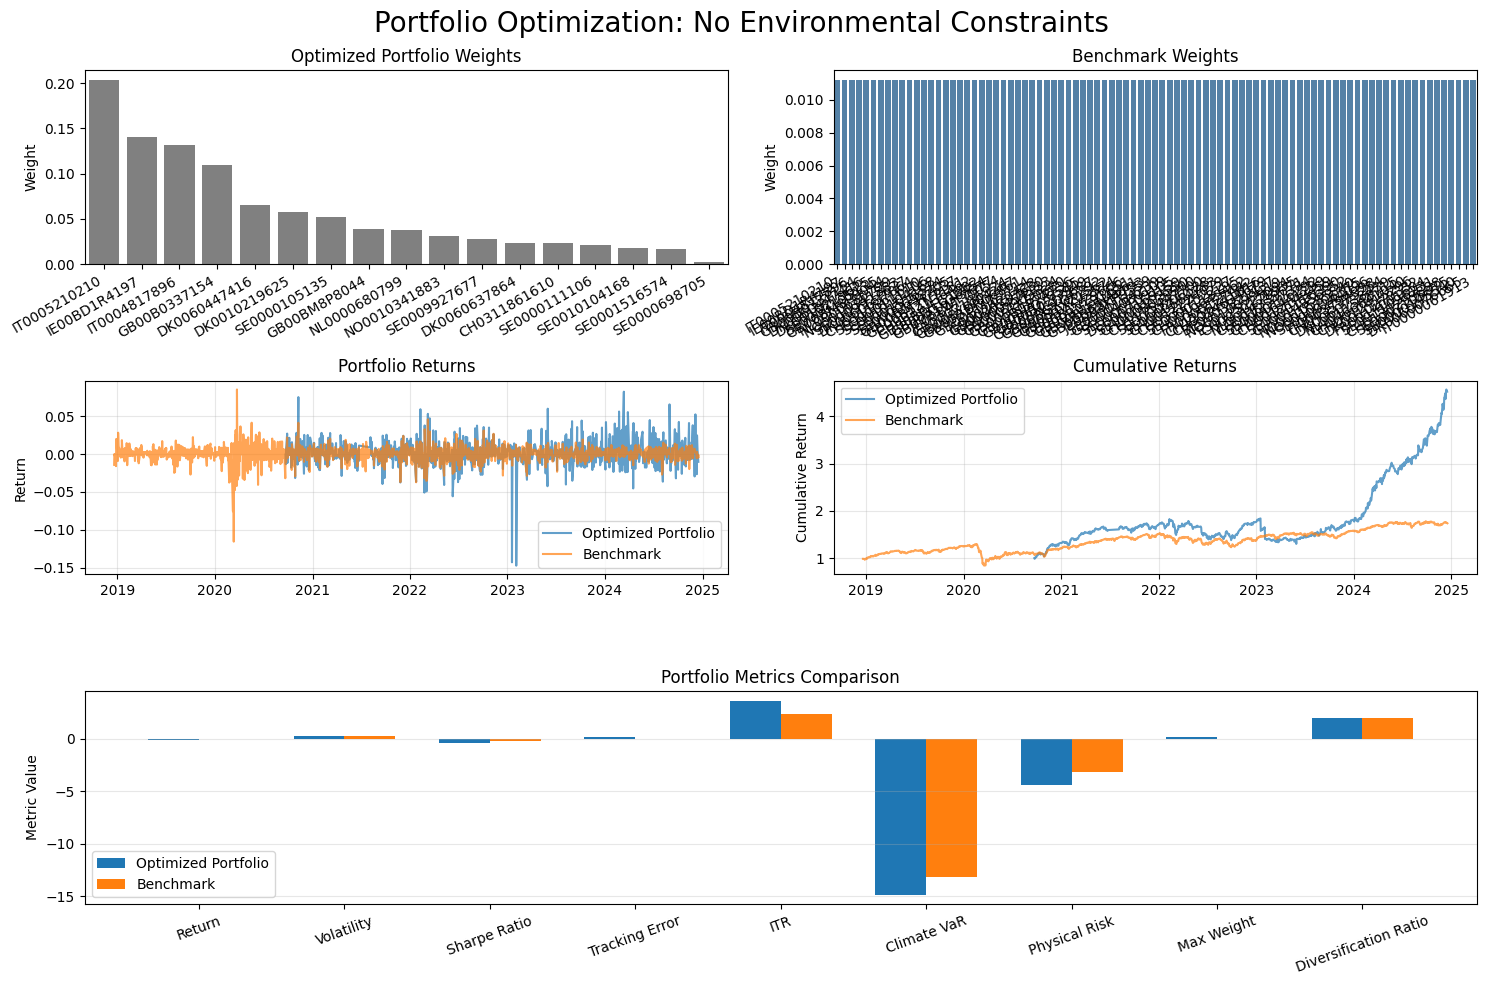

In [43]:
portfolio_no_env_constr = get_portfolio(w_no_env_constr, 
    assets=assets, returns=returns, 
    mu=mu, cov=cov, 
    physical=physical, itr=itr, cvar=cvar,
    benchmark_=benchmark_
)

plot_dashboard_portfolio(portfolio_no_env_constr, "Portfolio Optimization: No Environmental Constraints")

Adding climate constraints has only a limited impact on the allocation:
- The portfolio composition remains close to the previous
- This suggests that climate thresholds are not strongly restrictive within the investment universe
- The selected assets already satisfy most climate conditions

The portfolio performance is similar to the previous. But we should interpret it carefully since the optimization is performed in-sample. Expected returns and covariance estimates are computed using the full dataset, introducing potential look-ahead bias

The climate-constrained portfolio improves climate and physical indicators moderately. The constraints successfully reduce climate exposure while preserving a similar financial profile.

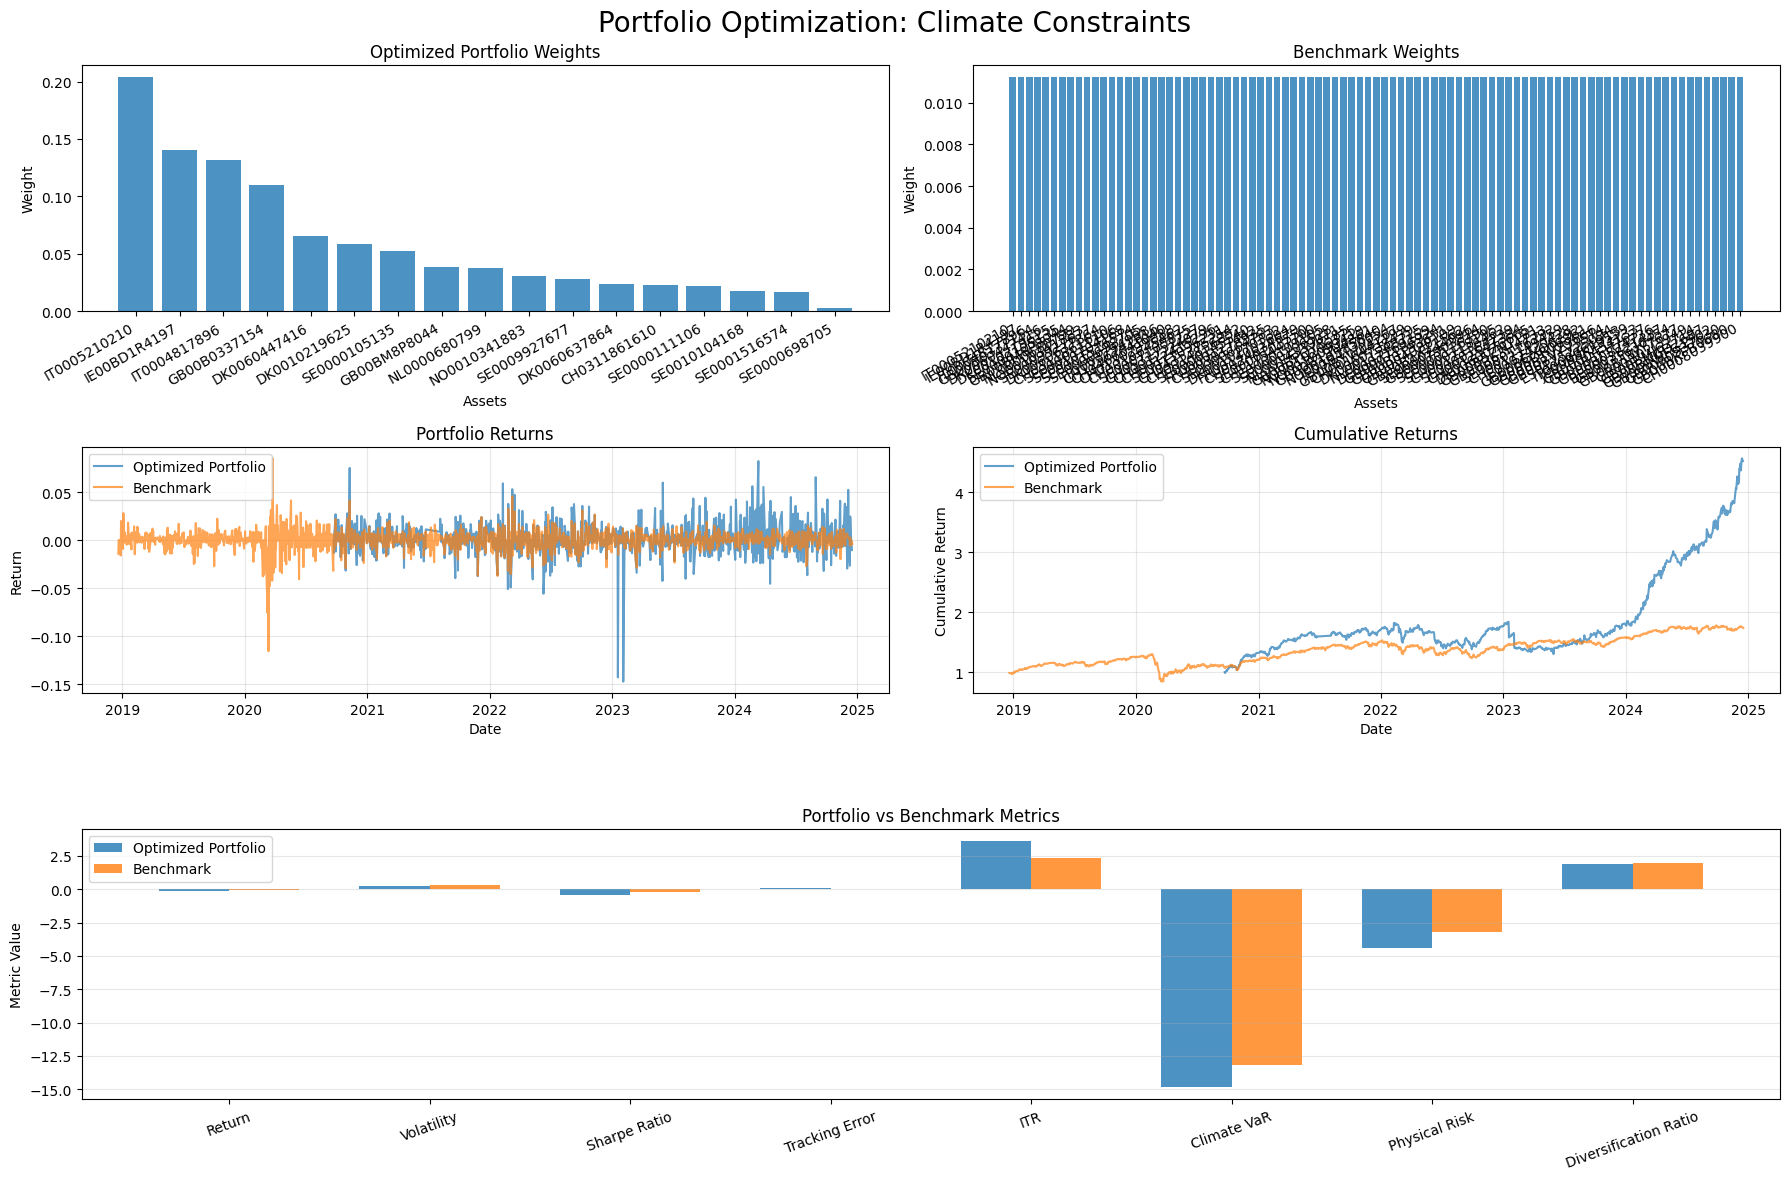

In [73]:
portfolio_climate_constr = get_portfolio(w_climate_constr, 
    assets=assets, returns=returns, 
    mu=mu, cov=cov, 
    physical=physical, itr=itr, cvar=cvar,
    benchmark_=benchmark_
)

plot_dashboard_portfolio(portfolio_climate_constr, "Portfolio Optimization: Climate Constraints")

The ESG-constrained portfolio is structurally different:
- The allocation becomes more diversified, with a larger number of assets receiving positive weights
- The ESG requirement forces the optimizer to include additional securities that may not be selected under pure financial optimization

The portfolio generates lower cumulative returns and underperforms the benchmark over part of the sample. The ESG constraint introduces a clear performance trade-off, as the optimizer sacrifices part of the financial efficiency to satisfy sustainability requirements

The ESG-constrained portfolio  achieves the strongest reduction in climate-related risks, but at the cost of higher volatility and lower return efficiency.

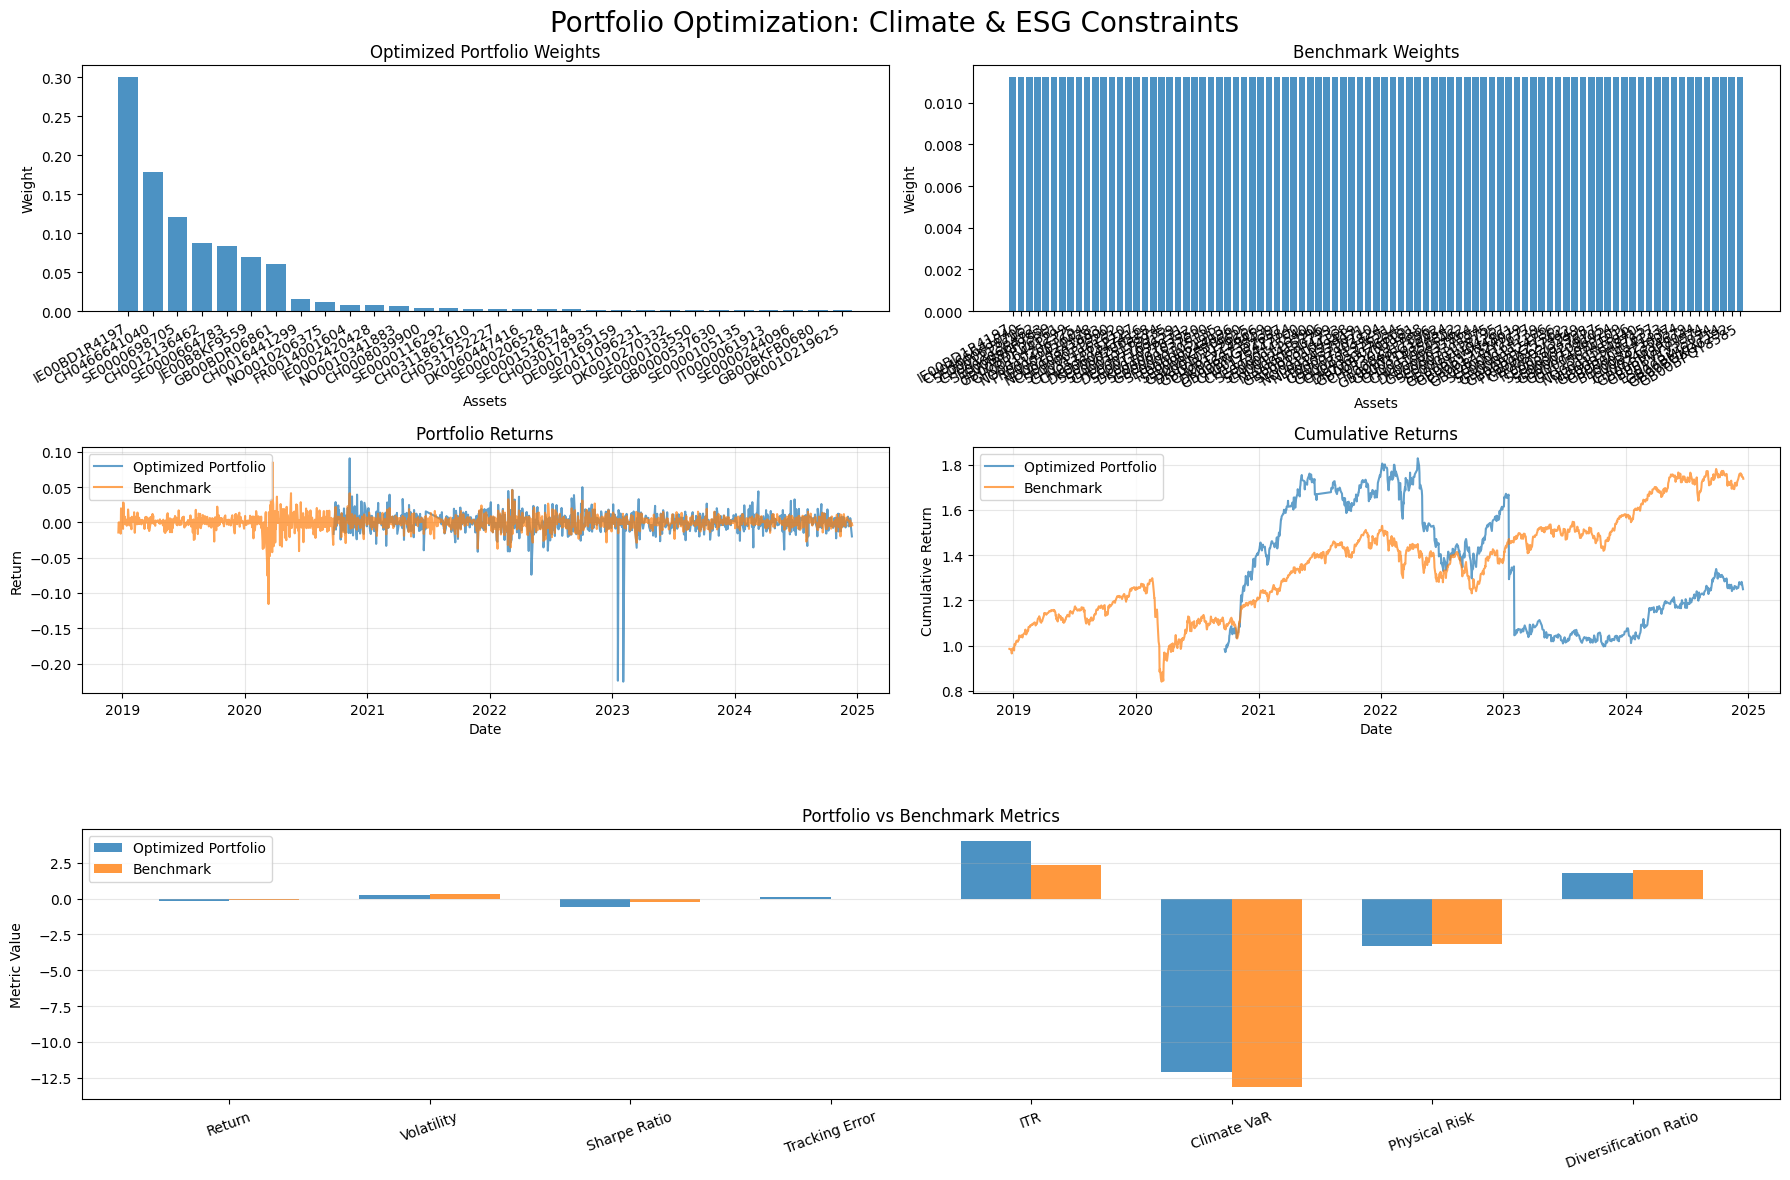

In [72]:
portfolio_climate_esg_constr = get_portfolio(w_climate_esg_constr, 
    assets=assets, returns=returns, 
    mu=mu, cov=cov, 
    physical=physical, itr=itr, cvar=cvar,
    benchmark_=benchmark_
)

plot_dashboard_portfolio(portfolio_climate_esg_constr, "Portfolio Optimization: Climate & ESG Constraints")

__________________

# III. Mean-Variance Optimization


|   **Minimum variance (Efficient Frontier)**    |      **Global Minimum Variance portfolio (GMV)**       |    **Tangency portfolio (Maximum Sharpe ratio)**        |
|------------|-----------|---------|
|      Minimize variance for a required expected portfolio return $\mathbb{E}[R_p]$  $$ \begin{aligned} \min_{w}\quad & w^T \Sigma\, w   \quad\quad\quad \text{s.t.} \ & \begin{cases} w^T \mu = E[R_p]   \\[6pt] \mathbf{1}^T w = 1  \\[6pt] 0 \le w_i \le 1 \end{cases} \end{aligned}$$     |               Minimize variance   $$ \begin{aligned} \min_{w}\quad & w^T \Sigma\, w   \quad\quad\quad \text{s.t.} \ & \begin{cases} \mathbf{1}^T w = 1  \\[6pt] 0 \le w_i \le 1   \end{cases} \end{aligned}$$     |      Maximize the Sharpe ratio:  $$ \begin{aligned} \max_{w}\quad & \dfrac{w^T \mu - r_f}{\sqrt{\,w^T \Sigma\, w\,}}   \quad\quad\quad \text{s.t.} \ & \begin{cases} \mathbf{1}^T w = 1 \\[6pt] 0 \le w_i \le 1   \end{cases} \end{aligned}$$  |  



In [38]:
def compute_efficient_frontier(
    assets=assets, mu=mu, cov=cov, 
    esg_scores=None, physical=None, itr=None, cvar=None, cluster_map=None,
):
    frontier_returns, frontier_risks= [], []
    target_returns = np.linspace(mu.min(), mu.max(), 20)
    for r_target in target_returns:
        # Variables
        n = len(assets)
        w = cp.Variable(n)
        portfolio_return = mu.values @ w
        portfolio_risk = cp.quad_form(w, cov.values)

        w_b = np.ones(n) / n
        tracking_error = cp.quad_form(w - w_b, cov.values)

        portfolio_itr, portfolio_esg, portfolio_phys, portfolio_cvar = None, None, None, None
        if physical is not None:
            portfolio_phys = physical.values @ w
        if itr is not None:
            portfolio_itr = itr.values @ w
        if cvar is not None:
            portfolio_cvar = cvar.values @ w
        if esg_scores is not None:
            portfolio_esg = esg_scores.values @ w
        constraints = get_constraints(w=w, tracking_error=tracking_error,
            esg_scores=esg_scores, physical=physical, itr=itr, cvar=cvar, cluster_map=cluster_map,
            portfolio_esg=portfolio_esg, portfolio_phys=portfolio_phys, portfolio_itr=portfolio_itr, portfolio_cvar=portfolio_cvar
        )
        constraints += [portfolio_return == r_target]

        # Objective: minimize risk
        objective = cp.Minimize(portfolio_risk)
        problem = cp.Problem(objective, constraints)
        try:
            problem.solve(solver=cp.SCS)
            if w.value is not None:
                w_opt = w.value
                frontier_returns.append(portfolio_return.value)
                frontier_risks.append(np.sqrt(portfolio_risk.value))
        except:
            continue
    return frontier_returns, frontier_risks

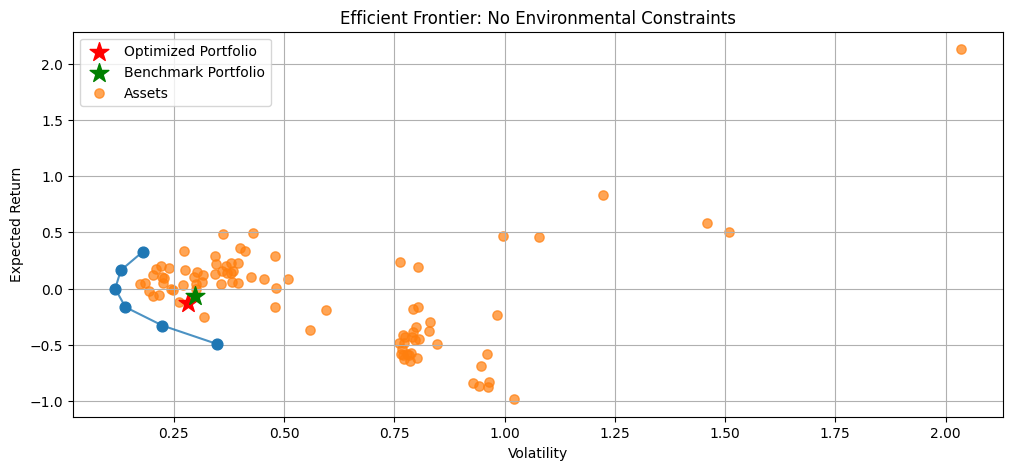

In [82]:
frontiers_no_env_constr = compute_efficient_frontier()
plot_efficient_frontier(
    frontiers=frontiers_no_env_constr, portfolio_dict=portfolio_no_env_constr, cov=cov, mu=mu,
    title="Efficient Frontier: No Environmental Constraints"
)
plt.show()

The optimized portfolio and benchmark are both located near the low-volatility region of the frontier, suggesting conservative risk positioning under the imposed constraints

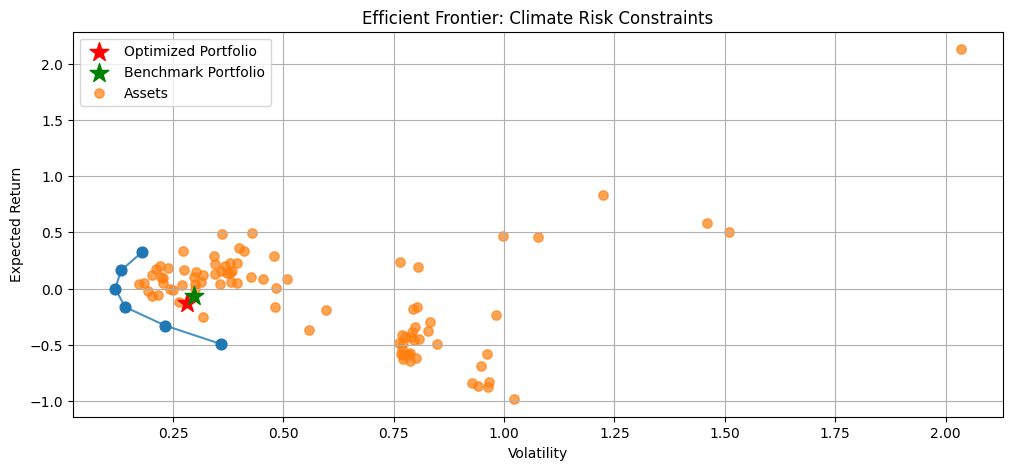

In [81]:
frontiers_climate_constr = compute_efficient_frontier(physical=physical, itr=itr, cvar=cvar)
plot_efficient_frontier(
    frontiers=frontiers_climate_constr, portfolio_dict=portfolio_climate_constr, cov=cov, mu=mu,
    title="Efficient Frontier: Climate Risk Constraints"
)
plt.show()

Adding ESG constraints changes the frontier more substantially:
- The feasible region becomes wider and less regular, with higher achievable volatility levels
- ESG eligibility modifies the optimization universe and forces the inclusion of assets that differ from the purely mean-variance optimal set

(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier: Climate Risk + ESG Constraints'}, xlabel='Volatility', ylabel='Expected Return'>)

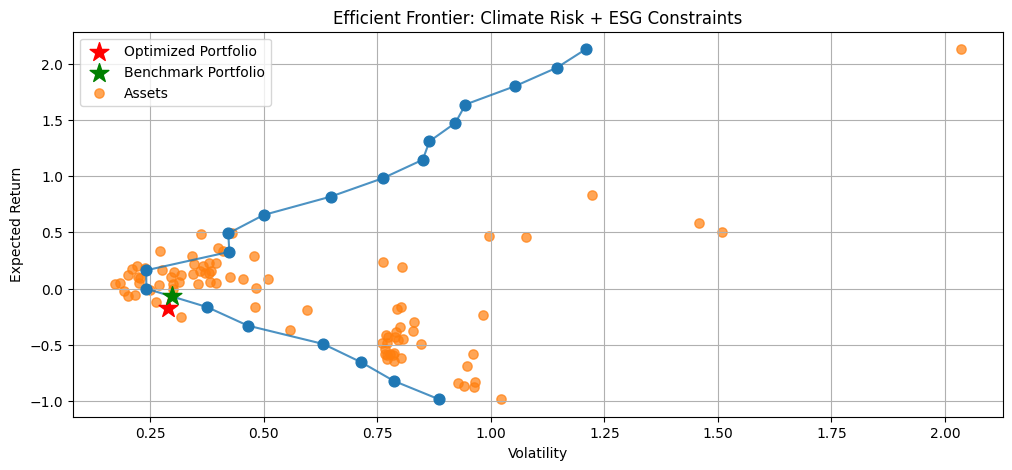

In [ ]:
frontiers_climate_esg_constr = compute_efficient_frontier(physical=physical, itr=itr, cvar=cvar, esg_scores=esg_scores)
plot_efficient_frontier(
    frontiers=frontiers_climate_esg_constr, portfolio_dict=portfolio_climate_esg_constr, cov=cov, mu=mu,
    title="Efficient Frontier: Climate Risk + ESG Constraints"
)
plt.show()

### Comparing Efficient Frontiers

The climate-constrained efficient frontier remains close to the unconstrained frontier:
- This indicates that the imposed climate constraints do not significantly reduce the feasible investment set


The comparison between frontiers highlights 3 key results:
* the unconstrained and climate-constrained frontiers are almost identical
* climate constraints alone have limited impact on portfolio efficiency
* ESG constraints materially alter the portfolio construction and the risk-return trade-off


The results suggest that the climate thresholds used in this study are relatively non-binding, whereas ESG constraints have a much stronger influence on the optimization process and portfolio structure

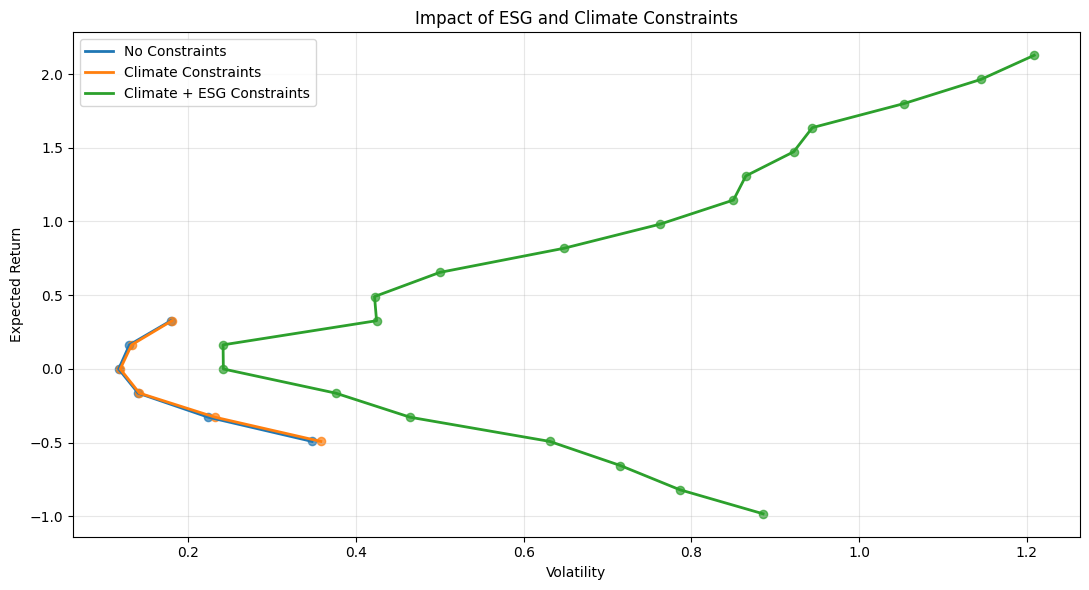

In [85]:
frontiers_dict = {
    "No Constraints": frontiers_no_env_constr,
    "Climate Constraints": frontiers_climate_constr,
    "Climate + ESG Constraints": frontiers_climate_esg_constr,
}

plot_multiple_frontiers(
    frontiers_dict,
    title="Impact of ESG and Climate Constraints"
)

plt.show()